# Colon Cancer Precision Oncology

Ce notebook presente une analyse simple pour classifier l'etat d'un patient a partir de 6 genes d'expression genetique.

Objectif : entrainer une Logistic Regression capable de predire `Normal` ou `Abnormal`.

## 1. Import des bibliotheques

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

## 2. Chargement du dataset

In [2]:
DATA_PATH = Path('../data/colon_cancer.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/colon_cancer.csv')

df = pd.read_csv(DATA_PATH)
df.head()

,0,H55933,R39465,R39465_,R85482,U14973,R02593,T51496,H80240,T65938,...,R70790,L11706,T90549,D17390,M33210,H18490,H40891,R77780,T49647,Class
0,1,8589.4160,5468.2407,4263.4077,4064.9358,1997.8930,5282.3250,2169.7200,2773.4211,7526.3860,...,67.56125,259.91250,138.89874,88.23250,39.66786,67.82875,75.67750,83.52250,28.70125,Abnormal
1,2,9164.2540,6719.5293,4883.4487,3718.1590,2015.2214,5569.9070,3849.0588,2793.3875,7017.7340,...,92.23875,96.27625,150.59000,82.23750,85.03333,152.19500,186.56750,44.47250,16.77375,Normal
2,3,3825.7050,6970.3613,5369.9688,4705.6500,1166.5536,1572.1678,1325.4025,1472.2587,3296.9512,...,82.71500,31.10250,193.92000,76.97250,224.62024,31.22500,42.65625,16.09250,15.15625,Abnormal
3,4,6246.4487,7823.5340,5955.8350,3975.5642,2002.6132,2130.5430,1531.1425,1714.6312,3869.7850,...,41.68375,5.92500,183.00626,74.52875,67.71072,48.33875,42.52000,49.98250,16.08500,Normal
4,5,3230.3286,3694.4500,3400.7400,3463.5857,2181.4202,2922.7820,2069.2463,2948.5750,3303.3710,...,76.60375,161.35000,61.70125,54.56375,223.35953,73.09875,57.59875,7.48875,31.81250,Abnormal


Ce tableau représente les 5 premières lignes du dataset. Chaque ligne correspond à un échantillon d’un patient, et chaque colonne correspond à une valeur d’expression génétique d’un gène précis.

Les valeurs numériques montrent le niveau d’activité de chaque gène chez le patient.

La dernière colonne, Class, est la variable qu’on veut prédire avec le modèle de machine learning. Elle contient deux classes : Normal et Abnormal.

On remarque que le dataset contient beaucoup de colonnes, environ 2002. Cela signifie qu’il y a beaucoup de gènes. Pour simplifier le projet, on n’a pas utilisé tous les gènes, mais seulement 6 gènes sélectionnés afin d’avoir un modèle plus simple, plus compréhensible et plus facile à déployer dans une application web.

## 3. Exploration rapide

In [3]:
print('Dimensions:', df.shape)
print('Colonnes:', list(df.columns))
print('\nRepartition des classes:')
print(df['Class'].value_counts())

Dimensions: (62, 2002)
Colonnes: ['0', 'H55933', 'R39465', 'R39465_', 'R85482', 'U14973', 'R02593', 'T51496', 'H80240', 'T65938', 'T55131', 'T72863', 'H86060_', 'X63432', 'H20709', 'U14971', 'T52342', 'L28809', 'T63508', 'H09263', 'T49423', 'H79852', 'J02763', 'R22197', 'T59954', 'H80240_', 'T95018', 'H86060', 'T63484', 'R02593_', 'M11799', 'T61609', 'T62220', 'T51574', 'T48041', 'T96832', 'H54676', 'R86975', 'T63258', 'control1', 'control2', 'control3', 'control', 'T57619', 'T88723', 'R36455', 'T61602', 'T58861', 'U21909', 'T61661', 'control4', 'control5', 'control6', 'control7', 'T52015', 'H24754', 'H22688', 'T93094', 'T51560', 'U12255', 'R01182', 'R74349', 'T48804', 'H77302', 'M14630', 'T63499', 'T71025', 'T51534', 'T69026', 'H68220', 'T61661_', 'X57346', 'H55758', 'H43908', 'H79575', 'X55715', 'H13281', 'R49974', 'R42570', 'T47645', 'M24398', 'H43908_', 'M31013', 'H05803', 'T56674', 'T68848', 'T72938', 'M94345', 'R50158', 'D12686', 'U09873', 'T47144', 'H64398', 'T87873', 'M11354', 

Ici, j'ai vérifié la structure du dataset. Il contient 62 échantillons et 2002 colonnes. La plupart des colonnes sont des gènes, et la colonne Class représente la classe réelle du patient : Normal ou Abnormal. On remarque aussi que le dataset contient plus de cas Abnormal que Normal, avec 40 cas Abnormal contre 22 cas Normal. Cette information est importante, car elle nous permet de comprendre la distribution des données avant l’entraînement du modèle.

In [4]:
df.describe()

,0,H55933,R39465,R39465_,R85482,U14973,R02593,T51496,H80240,T65938,...,X67699,R70790,L11706,T90549,D17390,M33210,H18490,H40891,R77780,T49647
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,...,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,31.500000,7015.786703,4966.959971,4094.727906,3987.789302,2937.126132,4705.119294,3588.800302,2872.288627,4680.191126,...,186.204532,100.227903,293.222722,124.653387,133.186935,184.136636,84.118387,114.930000,53.251230,42.965827
std,18.041619,3092.970593,2188.890465,1818.080945,2019.086906,1356.932895,2400.848121,1872.106074,1122.365445,2417.239210,...,117.605889,78.022713,179.249194,75.535838,101.372557,159.914871,86.182028,88.011866,38.462814,28.395175
min,1.000000,1914.677500,1383.488600,1269.648700,1186.030400,1166.553600,1087.750000,1062.697500,1026.477500,995.790000,...,5.950000,5.935000,5.925000,5.923750,5.916250,5.888095,5.878750,5.848750,5.842500,5.816250
25%,16.250000,4877.364750,3408.951225,2763.725975,2648.942800,1890.857050,2843.368825,2112.952225,2050.814050,2971.792800,...,117.778870,48.409375,161.518125,69.121250,71.637500,85.905057,30.701875,53.881563,27.334375,24.610000
50%,31.500000,6274.612550,4738.280500,3890.338150,3451.498150,2666.075700,4416.617650,3438.180000,2844.960650,4088.735500,...,152.722625,83.080625,251.883125,114.658125,104.271875,142.578565,56.385625,93.825625,45.358125,34.775000
75%,46.750000,8712.283250,6455.843300,5008.993925,4738.408950,3563.969400,6076.031850,4420.645200,3414.228475,6171.382750,...,247.298513,117.208438,424.742500,177.730310,149.772188,212.019948,101.231250,145.074062,66.235312,54.697500
max,62.000000,14876.407000,10152.273000,8605.044000,11248.680000,8093.875000,11222.682000,9939.246000,5917.026400,14144.835000,...,725.338100,438.383760,902.572500,333.418760,464.930000,702.130900,405.600000,390.890000,197.220000,126.826250


### Interprétation 

df.describe() donne un résumé statistique des colonnes numériques du dataset. Ici, il affiche les statistiques de 2001 colonnes numériques, parce que la colonne Class n’est pas numérique, donc elle n’apparaît pas dans ce résumé.

Chaque colonne représente généralement une valeur d’expression génétique. Pour chaque gène, on obtient plusieurs informations :

count = 62 signifie que chaque colonne contient 62 valeurs, donc on a 62 échantillons. Cela montre qu’il n’y a pas de valeurs manquantes dans ces colonnes numériques.

mean représente la moyenne des valeurs pour chaque gène. Par exemple, pour le gène H55933, la moyenne est environ 7015.78. Cela donne une idée du niveau moyen d’expression de ce gène dans tous les patients.

std représente l’écart-type. Il montre à quel point les valeurs varient autour de la moyenne. Quand l’écart-type est grand, cela veut dire que l’expression du gène varie beaucoup entre les patients. Par exemple, H55933 a un écart-type d’environ 3092.97, donc ses valeurs sont très dispersées.

min et max montrent les valeurs minimale et maximale observées pour chaque gène. On remarque que certaines valeurs peuvent être très grandes. Par exemple, pour H55933, la valeur minimale est environ 1914.67 et la valeur maximale est 14876.40. Cela montre que certains gènes ont des niveaux d’expression très différents selon les patients.

Les valeurs 25%, 50% et 75% sont les quartiles.
50% correspond à la médiane, c’est-à-dire la valeur centrale. Par exemple, pour H55933, la médiane est environ 6274.61. Cela permet de comprendre la distribution des valeurs sans être trop influencé par les valeurs extrêmes.

On remarque aussi que les gènes n’ont pas tous la même échelle. Certains ont des valeurs très grandes, d’autres beaucoup plus petites. C’est pour cela qu’on utilise un StandardScaler avant la régression logistique. Le scaler permet de mettre les gènes sur une échelle comparable, afin que le modèle ne soit pas influencé uniquement par les gènes qui ont les plus grandes valeurs numériques.

## 4. Verification des 6 genes

In [5]:
features = ['M63391', 'T62947', 'D14812', 'T51250', 'H66976', 'X55362']
target_column = 'Class'

missing = [column for column in features + [target_column] if column not in df.columns]
if missing:
    raise ValueError(f'Colonnes manquantes: {missing}')

print('Toutes les colonnes necessaires sont presentes.')

Toutes les colonnes necessaires sont presentes.


## 5. Visualisation simple des classes

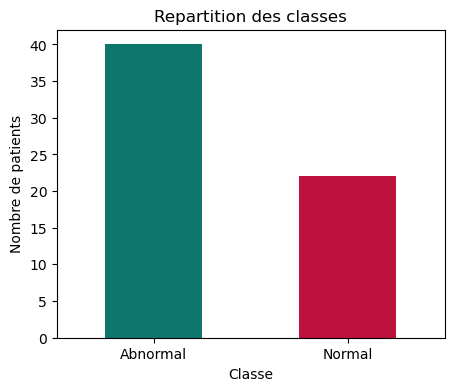

In [6]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['#0f766e', '#be123c'])
plt.title('Repartition des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.show()

### Interprétation 
Ce graphique montre la répartition des classes dans notre dataset.

On observe qu’il y a deux classes :

- Abnormal
- Normal

La classe Abnormal contient environ 40 patients, tandis que la classe Normal contient environ 22 patients.

Cela signifie que notre dataset n’est pas parfaitement équilibré : il contient plus de cas Abnormal que de cas Normal.

Cette information est importante avant l’entraînement du modèle, parce qu’un déséquilibre entre les classes peut influencer l’apprentissage. Par exemple, le modèle peut apprendre plus facilement à reconnaître la classe la plus représentée, ici Abnormal.

## 6. Separation train/test et encodage des labels

In [7]:
X = df[features]
y = df[target_column]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)
print('Classes:', list(label_encoder.classes_))

Train: (49, 6)
Test: (13, 6)
Classes: ['Abnormal', 'Normal']


## 7. Standardisation avec StandardScaler

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Entrainement Logistic Regression

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 9. Evaluation du modele

In [10]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
cm_df

Accuracy: 0.9231


,Abnormal,Normal
Abnormal,8,0
Normal,1,4


In [11]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    Abnormal       0.89      1.00      0.94         8
      Normal       1.00      0.80      0.89         5

    accuracy                           0.92        13
   macro avg       0.94      0.90      0.92        13
weighted avg       0.93      0.92      0.92        13



### Interprétation 
Le modèle a obtenu une accuracy de 0.9231, c’est-à-dire environ 92.31%.
Cela veut dire que sur les 13 patients du test, le modèle a bien classé 12 patients et s’est trompé sur 1 seul patient.

La matrice de confusion montre ceci :

                 Prédit Abnormal   Prédit Normal
Réel Abnormal          8                0
Réel Normal            1                4

Interprétation :

Le modèle a correctement reconnu les 8 patients Abnormal. Il n’a raté aucun cas Abnormal.
Pour les patients Normal, il en a correctement reconnu 4, mais il a classé 1 patient Normal comme Abnormal.

Donc l’erreur du modèle est une fausse alerte : un patient réellement Normal a été prédit comme Abnormal.

Pour la classe Abnormal :

precision = 0.89
recall = 1.00
f1-score = 0.94

Cela signifie que le modèle détecte très bien les cas Abnormal. Le recall = 1.00 veut dire qu’il a trouvé tous les vrais cas Abnormal dans le test.

Pour la classe Normal :

precision = 1.00
recall = 0.80
f1-score = 0.89

Cela veut dire que quand le modèle prédit Normal, il est très fiable. Mais il a raté un cas Normal, car il l’a prédit Abnormal.

## 10. Lecture des coefficients

In [12]:
coef_df = pd.DataFrame({
    'gene': features,
    'coefficient': model.coef_[0],
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,gene,coefficient
1,T62947,-1.715064
0,M63391,1.566051
2,D14812,-0.864455
3,T51250,0.740612
4,H66976,0.424863
5,X55362,-0.210146


### Interprétation
Dans la régression logistique, chaque gène a un coefficient. Ce coefficient montre l’influence du gène sur la prédiction du modèle.

Ici, les classes sont :

['Abnormal', 'Normal']

Avec LabelEncoder, généralement :

Abnormal = 0
Normal = 1

Donc, dans ce cas :

coefficient positif → pousse la prédiction vers Normal
coefficient négatif → pousse la prédiction vers Abnormal
Interprétation des gènes
T62947 : -1.715064

C’est le coefficient le plus négatif. Cela veut dire que ce gène a une forte influence vers la classe Abnormal.

M63391 : 1.566051

C’est le coefficient positif le plus fort. Il pousse fortement la prédiction vers la classe Normal.

D14812 : -0.864455

Ce gène influence aussi la prédiction vers Abnormal, mais moins fortement que T62947.

T51250 : 0.740612
H66976 : 0.424863

Ces deux gènes poussent plutôt vers Normal, avec une influence positive.

X55362 : -0.210146

Ce gène a une influence vers Abnormal, mais son effet est faible par rapport aux autres.

## 11. Pourquoi ces 6 genes ?

Dans ce projet, les 6 genes sont traites comme un panel reduit de biomarqueurs. L'interet pedagogique est de montrer un pipeline complet avec peu de variables : chargement des donnees, pretraitement, entrainement, evaluation et deploiement.

Un nombre limite de genes rend le modele plus simple a expliquer pendant une presentation. En pratique clinique, le choix des genes devrait etre valide par des analyses biologiques, statistiques et medicales plus completes.